In [65]:
import pandas as pd
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

In [ ]:
data_path = "/Users/sana/Downloads/STAT390/Data/CAR_-_EP_Flow_Activity_Queue__Agent_Names"

In [67]:
folder = Path(data_path)
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.xlsx")))
df_main = pd.DataFrame(columns=['Contact Session ID', 'EP Name', 'Flow Name', 'Activity Name', 'Activity Start Timestamp', 
                                'Queue Name', 'Agent Name', 'Termination Reason'])
df_main

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason


In [68]:
i=0
for f in files:
    i = i + 1
    if f.suffix.lower() == ".csv":
        df = pd.read_csv(f, header=2, dtype=str, engine="python", skip_blank_lines=False)
    else:  # .xlsx
        df = pd.read_excel(f, sheet_name=0, header=2, dtype=str)
    df_main = pd.concat([df_main, df], ignore_index=True)
    print(i, f.stem, df.shape)

1 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 3-16 to 3-22-25 (45326, 8)
2 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 3-30 to 4-5-25 (45072, 8)
3 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 4-13 to 4-19-25 (41088, 8)
4 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 4-20 to 4-26-25 (46686, 8)
5 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 4-27 to 5-3-25 (44169, 8)
6 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 4-6 to 4-12-25 (46630, 8)
7 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 5-11 to 5-17-25 (43268, 8)
8 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 5-18 to 5-24-25 (45104, 8)
9 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 5-25 to 5-31-25 (36851, 8)
10 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 5-4 to 5-10-25 (43955, 8)
11 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 6-1 to 6-7-25 (44523, 8)
12 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 6-15 to 6-21-25 (37234, 8)
13 CAR - EP, Flow, Activity, Queue, &amp; A

In [71]:
df_main["Activity Start Timestamp"] = pd.to_datetime(df_main["Activity Start Timestamp"], errors="coerce")
# Creating a new column 'hour' as it will be useful to visualize peak calling hours
#df_main["hour"] = df_main["Activity Start Timestamp"].dt.hour
#df_main["weekday"] = df_main["Activity Start Timestamp"].dt.day_name()

/var/folders/js/ymz6mb411xbdbhb1g8hh6rvr0000gn/T/ipykernel_76630/19692311.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_main["Activity Start Timestamp"] = pd.to_datetime(df_main["Activity Start Timestamp"], errors="coerce")


In [ ]:
df_main.head()
#df_main['Contact Session ID'].nunique()


,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason
0,ced63a4a-89f4-4e11-94b3-447a01cd34cb,Main Number Telephony EP,NaN,NaN,2025-03-16 00:40:10,NaN,NaN,NaN
1,ced63a4a-89f4-4e11-94b3-447a01cd34cb,NaN,LACMain,NaN,2025-03-16 00:40:10,NaN,NaN,NaN
2,ced63a4a-89f4-4e11-94b3-447a01cd34cb,Main Number Telephony EP,NaN,LanguageSelectionMenu,2025-03-16 00:40:10,NaN,NaN,NaN
3,ced63a4a-89f4-4e11-94b3-447a01cd34cb,Main Number Telephony EP,LACMain,NaN,2025-03-16 00:40:10,NaN,NaN,NaN
4,ced63a4a-89f4-4e11-94b3-447a01cd34cb,Main Number Telephony EP,NaN,NaN,2025-03-16 00:40:12,NaN,NaN,Customer Left


In [82]:
# Create sequential call_id correctly

df_main.sort_values(
    by=['Contact Session ID', 'Activity Start Timestamp']
)
df_main_sorted = df_main['call_id'] = (
    (df_main['Contact Session ID'] != 
     df_main['Contact Session ID'].shift())
    .cumsum()
)

# REORDER COLUMNS
column_order = [
    'call_id',
    'Contact Session ID',
    'EP Name',
    'Flow Name',
    'Activity Name',
    'Activity Start Timestamp',
    'Queue Name',
    'Agent Name',
    'Termination Reason']
df_main = df_main[column_order]

df_main.head()

,call_id,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason
0,1,ced63a4a-89f4-4e11-94b3-447a01cd34cb,Main Number Telephony EP,NaN,NaN,2025-03-16 00:40:10,NaN,NaN,NaN
1,1,ced63a4a-89f4-4e11-94b3-447a01cd34cb,NaN,LACMain,NaN,2025-03-16 00:40:10,NaN,NaN,NaN
2,1,ced63a4a-89f4-4e11-94b3-447a01cd34cb,Main Number Telephony EP,NaN,LanguageSelectionMenu,2025-03-16 00:40:10,NaN,NaN,NaN
3,1,ced63a4a-89f4-4e11-94b3-447a01cd34cb,Main Number Telephony EP,LACMain,NaN,2025-03-16 00:40:10,NaN,NaN,NaN
4,1,ced63a4a-89f4-4e11-94b3-447a01cd34cb,Main Number Telephony EP,NaN,NaN,2025-03-16 00:40:12,NaN,NaN,Customer Left


In [ ]:
# creating next_termination_reason column
df_main = df_main.sort_values(['call_id', 'Activity Start Timestamp'])
df_main['next_termination_reason'] = (
    df_main.groupby('call_id')['Termination Reason']
    .shift(-1)
)

In [ ]:
## number of calls that enter any part of the housing flow 
housing_activities = ['HousingMenu', 'PreTenantMenu', 'TenantMenu', 'TenantDeterrenceMenu']

calls_with_housing_flow = df_main.loc[df_main['Activity Name'].isin(housing_activities), 'call_id'].unique()

calls_housing_flow_df = df_main[df_main['call_id'].isin(calls_with_housing_flow)].sort_values(
    ['call_id', 'Activity Start Timestamp']
)

calls_housing_flow_df['call_id'].nunique()
call_housing_flow_df = calls_housing_flow_df.sort_values(
    ['call_id', 'Activity Start Timestamp']
)
calls_housing_flow_df['call_id'].nunique()


22232

In [ ]:
# function to categorize calls based on menu flow and Customer Left behavior 
def categorize_full_with_same_row(path, term):
    
    if 'Customer Left' not in term:
        return 'No leave'
    
    left_index = term.index('Customer Left')
    path_before_leave = path[:left_index+1]

    # ----------------------------
    # TenantDeterrenceMenu
    # ----------------------------
    if 'TenantDeterrenceMenu' in path_before_leave:
        td_index = path_before_leave.index('TenantDeterrenceMenu')
        # Same row leave
        if td_index == left_index:
            return 'Left in same row as TenantDeterrenceMenu'
        # Backtracking
        if 'TenantMenu' in path_before_leave[td_index+1:]:
            tenant_index = td_index + 1 + path_before_leave[td_index+1:].index('TenantMenu')
            if tenant_index == left_index - 1:
                return 'Left immediately after back to TenantMenu'
            else:
                return 'Left after back to TenantMenu'
        if 'HousingMenu' in path_before_leave[td_index+1:]:
            housing_index = td_index + 1 + path_before_leave[td_index+1:].index('HousingMenu')
            if housing_index == left_index - 1:
                return 'Left immediately after back to HousingMenu'
            else:
                return 'Left after back to HousingMenu'
        # Direct leave after TD
        if td_index == left_index - 1:
            return 'Left immediately after TenantDeterrenceMenu'

    # ----------------------------
    # TenantMenu
    # ----------------------------
    if 'TenantMenu' in path_before_leave:
        tenant_index = path_before_leave.index('TenantMenu')
        if tenant_index == left_index or tenant_index == left_index - 1:
            if 'PreTenantMenu' in path_before_leave:
                return 'Left immediately after TenantMenu'
            return 'Left immediately after TenantMenu (no PreTenant?)'

    # ----------------------------
    # PreTenantMenu
    # ----------------------------
    if 'PreTenantMenu' in path_before_leave:
        pre_index = path_before_leave.index('PreTenantMenu')
        if pre_index == left_index or pre_index == left_index - 1:
            return 'Left immediately after PreTenantMenu'

    # ----------------------------
    # HousingMenu
    # ----------------------------
    if 'HousingMenu' in path_before_leave:
        housing_index = path_before_leave.index('HousingMenu')
        if housing_index == left_index or housing_index == left_index - 1:
            return 'Left immediately after HousingMenu'

    # Anything else
    return 'Other'


In [ ]:
# get the call-level paths and termination reasons
call_paths = call_housing_flow_df.groupby('call_id')['Activity Name'].apply(list)
term_paths = call_housing_flow_df.groupby('call_id')['Termination Reason'].apply(list)

# apply categorization function per call
categories = {
    call_id: categorize_full_with_same_row(call_paths[call_id], term_paths[call_id])
    for call_id in call_paths.index
}

# convert to DataFrame
category_df = pd.DataFrame({
    'call_id': list(categories.keys()),
    'category': list(categories.values())
})

#count number of calls per category
call_counts = category_df['category'].value_counts()

print(call_counts)


category
No leave                                             21184
Left immediately after TenantMenu (no PreTenant?)      542
Other                                                  219
Left immediately after HousingMenu                     166
Left immediately after back to TenantMenu               45
Left immediately after TenantDeterrenceMenu             40
Left immediately after PreTenantMenu                    13
Left after back to TenantMenu                           12
Left immediately after TenantMenu                       11
Name: count, dtype: int64


In [ ]:
# for sanity checks: making datasets per category
category_df = pd.DataFrame(list(categories.items()), columns=['call_id', 'category'])


tenant_no_pre_ids = category_df[category_df['category'] == 'Left immediately after TenantMenu (no PreTenant?)']['call_id'].unique()

tenant_no_pre_df = df_main[df_main['call_id'].isin(tenant_no_pre_ids)].sort_values(
    ['call_id', 'Activity Start Timestamp']
)


housing_ids = category_df[category_df['category'] == 'Left immediately after HousingMenu']['call_id'].unique()

housing_df = df_main[df_main['call_id'].isin(housing_ids)].sort_values(
    ['call_id', 'Activity Start Timestamp']
)


tenant_tenant_deterrence_ids = category_df[category_df['category'] == 'Left immediately after back to TenantMenu']['call_id'].unique()

tenant_tenant_deterrence_df = df_main[df_main['call_id'].isin(tenant_tenant_deterrence_ids)].sort_values(
    ['call_id', 'Activity Start Timestamp']
)



tenant_deterrence_ids = category_df[category_df['category'] == 'Left immediately after TenantDeterrenceMenu']['call_id'].unique()

tenant_deterrence_df = df_main[df_main['call_id'].isin(tenant_deterrence_ids)].sort_values(
    ['call_id', 'Activity Start Timestamp']
)



pretenant_ids = category_df[category_df['category'] == 'Left immediately after PreTenantMenu']['call_id'].unique()

pretenant_df = df_main[df_main['call_id'].isin(pretenant_ids)].sort_values(
    ['call_id', 'Activity Start Timestamp']
)


navigate_tenant_ids = category_df[category_df['category'] == 'Left after back to TenantMenu']['call_id'].unique()

navigate_tenant_df = df_main[df_main['call_id'].isin(navigate_tenant_ids)].sort_values(
    ['call_id', 'Activity Start Timestamp']
)


tenant_ids = category_df[category_df['category'] == 'Left immediately after TenantMenu']['call_id'].unique()

tenant_df = df_main[df_main['call_id'].isin(tenant_ids)].sort_values(
    ['call_id', 'Activity Start Timestamp']
)


other_call_ids = category_df[category_df['category'] == 'Other']['call_id'].unique()

other_calls_df = df_main[df_main['call_id'].isin(other_call_ids)].sort_values(
    ['call_id', 'Activity Start Timestamp']
)


In [ ]:
## Looking at Other category
# Filter rows where the next termination reason is "Customer Left"
rows_before_leave = other_calls_df[other_calls_df['next_termination_reason'] == 'Customer Left']

# Get unique activity names that immediately precede the leave
unique_activities_before_leave = rows_before_leave['Activity Name'].dropna().unique()

# get the number of unique calls per activity
unique_calls_per_activity = rows_before_leave.groupby('Activity Name')['call_id'].nunique()

print("Unique activities preceding 'Customer Left':", unique_activities_before_leave)
print("\nNumber of unique calls per activity:")
print(unique_calls_per_activity)


Unique activities preceding 'Customer Left': ['ClosedQueueMenu' 'HousingMenu' 'LegalMenu2' 'IntakePreQueueMessage1'
 'PlayMOH300s' 'MainMenu']

Number of unique calls per activity:
Activity Name
ClosedQueueMenu           64
HousingMenu                3
IntakePreQueueMessage1     1
LegalMenu2                12
MainMenu                   1
PlayMOH300s                1
Name: call_id, dtype: int64


In [ ]:
## after examining Other category more closely, many customers leave without entering any activity so let's look at those calls (EP)
# Filter rows where next_termination_reason = 'Customer Left'
left_next_df = other_calls_df[other_calls_df['next_termination_reason'] == 'Customer Left']

# Filter rows where Activity Name is missing but EP Name exists
no_activity_df = other_calls_df[
    other_calls_df['Activity Name'].isna() &
    other_calls_df['EP Name'].notna()
]

# Get unique EP Names
unique_eps_no_activity = no_activity_df['EP Name'].unique()

ep_counts_no_activity = no_activity_df['EP Name'].value_counts()
print("\nEP Name counts (no activity):")
print(ep_counts_no_activity)



EP Name counts (no activity):
EP Name
Legal Housing Menu Telephony EP             224
Closed Queue Menu Telephony EP               90
Legal Menu Telephony EP                      24
Main Number Telephony EP                     15
All LAC Queues Telephony EP                   5
Pre-Legal Menu Seniors Menu Telephony EP      2
Name: count, dtype: int64


In [ ]:
# Filter the rows where EP Name matchess
target_eps = [
    'Legal Housing Menu Telephony EP',
    'Closed Queue Menu Telephony EP',
    'Legal Menu Telephony EP',
    'All LAC Queues Telephony EP'
]
left_after_ep = other_calls_df[other_calls_df['EP Name'].isin(target_eps)].copy()

# Get the call IDs for those cases
left_after_ep_ids = left_after_ep['call_id'].unique()

# Now get *all* rows for those calls, sorted by time
calls_with_context = other_calls_df[
    other_calls_df['call_id'].isin(left_after_ep_ids)
].sort_values(['call_id', 'Activity Start Timestamp'])

# For each call, shift Activity Name upward by one row so I can see the previou activity
calls_with_context['prev_activity'] = (
    calls_with_context.groupby('call_id')['Activity Name'].shift(1)
)

# Filter down to the rows that actually match those EPs (the leaving point)
leaving_rows = calls_with_context[
    calls_with_context['EP Name'].isin(target_eps)
][['call_id', 'EP Name', 'Activity Name', 'prev_activity']]

leaving_rows.head(20)


# Only keep rows where Activity Name exists (previous activity)
prev_activity_context = leaving_rows[
    leaving_rows['Activity Name'].isna() & leaving_rows['prev_activity'].notna()
][['call_id', 'EP Name', 'prev_activity']]

# Count occurrences of each combination of previous activity and EP
prev_activity_ep_counts = (
    prev_activity_context
    .groupby(['prev_activity', 'EP Name'])
    .size()
    .reset_index(name='count')
    .sort_values(['prev_activity', 'count'], ascending=[True, False])
)

print(prev_activity_ep_counts)



             prev_activity                          EP Name  count
0  ClinicVoicemailTransfer   Closed Queue Menu Telephony EP      2
1          ClosedQueueMenu   Closed Queue Menu Telephony EP     71
2              HousingMenu  Legal Housing Menu Telephony EP     32
3   IntakePreQueueMessage1      All LAC Queues Telephony EP      1
4               LegalMenu2          Legal Menu Telephony EP     12
5              PlayMOH300s      All LAC Queues Telephony EP      1
6     SubSeniorTenantQueue      All LAC Queues Telephony EP      1
7     TenantDeterrenceMenu  Legal Housing Menu Telephony EP      1
8               TenantMenu  Legal Housing Menu Telephony EP     71


In [ ]:
# looking at 'Left after back to TenantMenu'
navigate_tenant_df
navigate_tenant_df['call_id'].unique()
# Tenant Deterrence Menu back to Tenant Menu then back to Housing Menu then Left 10
# 2 Closed Queue
## ADD TO EXISTING TOTAL

array([ 55191, 138386, 147689, 148073, 153628, 178784, 196652, 241887,
       242285, 257330, 407891, 428181])

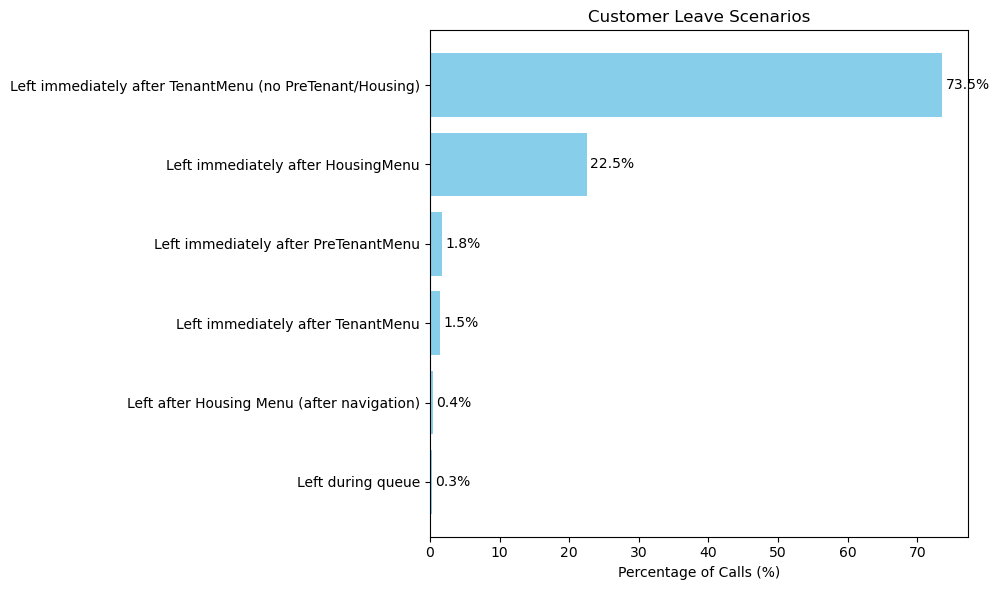

In [ ]:
## Creating graph 
import matplotlib.pyplot as plt

# Scenario labels
scenarios = [
    'Left immediately after TenantMenu (no PreTenant/Housing)',
    'Left immediately after HousingMenu',
    'Left immediately after PreTenantMenu',
    'Left immediately after TenantMenu',
    'Left after Housing Menu (after navigation)',
    'Left during queue'
]

# Counts for each scenario
counts = [542, 166, 13, 11, 3, 2]
total = sum(counts)
percentages = [count / total * 100 for count in counts]

plt.figure(figsize=(10,6))
bars = plt.barh(scenarios, percentages, color='skyblue')
plt.xlabel('Percentage of Calls (%)')
plt.title('Customer Leave Scenarios')
plt.gca().invert_yaxis()  # largest percentage on top

# ading percentage labelss
for bar, pct in zip(bars, percentages):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{pct:.1f}%', va='center')

plt.tight_layout()
plt.show()


In [225]:
df_main[df_main['call_id'] == 1390]


,call_id,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason,next_termination_reason
3200,1390,46bb9f14-7d4d-4e61-9069-9e29365d859d,Legal Housing Menu Telephony EP,NaN,TenantMenu,2025-03-17 10:25:17,NaN,NaN,NaN,NaN
3201,1390,46bb9f14-7d4d-4e61-9069-9e29365d859d,Legal Housing Menu Telephony EP,LegalHousingMenu,NaN,2025-03-17 10:25:17,NaN,NaN,NaN,Customer Left
3202,1390,46bb9f14-7d4d-4e61-9069-9e29365d859d,Legal Housing Menu Telephony EP,NaN,NaN,2025-03-17 10:25:17,NaN,NaN,Customer Left,NaN


In [158]:
## sanity check

td_left_df = df_main[
    (df_main['Activity Name'] == 'TenantDeterrenceMenu') &
    (df_main['next_termination_reason'] == 'Customer Left')
]
td_left_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 40 entries, 3557 to 1244548
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   call_id                   40 non-null     int64         
 1   Contact Session ID        40 non-null     object        
 2   EP Name                   40 non-null     object        
 3   Flow Name                 0 non-null      object        
 4   Activity Name             40 non-null     object        
 5   Activity Start Timestamp  40 non-null     datetime64[ns]
 6   Queue Name                0 non-null      object        
 7   Agent Name                0 non-null      object        
 8   Termination Reason        0 non-null      object        
 9   next_termination_reason   40 non-null     object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 3.4+ KB
